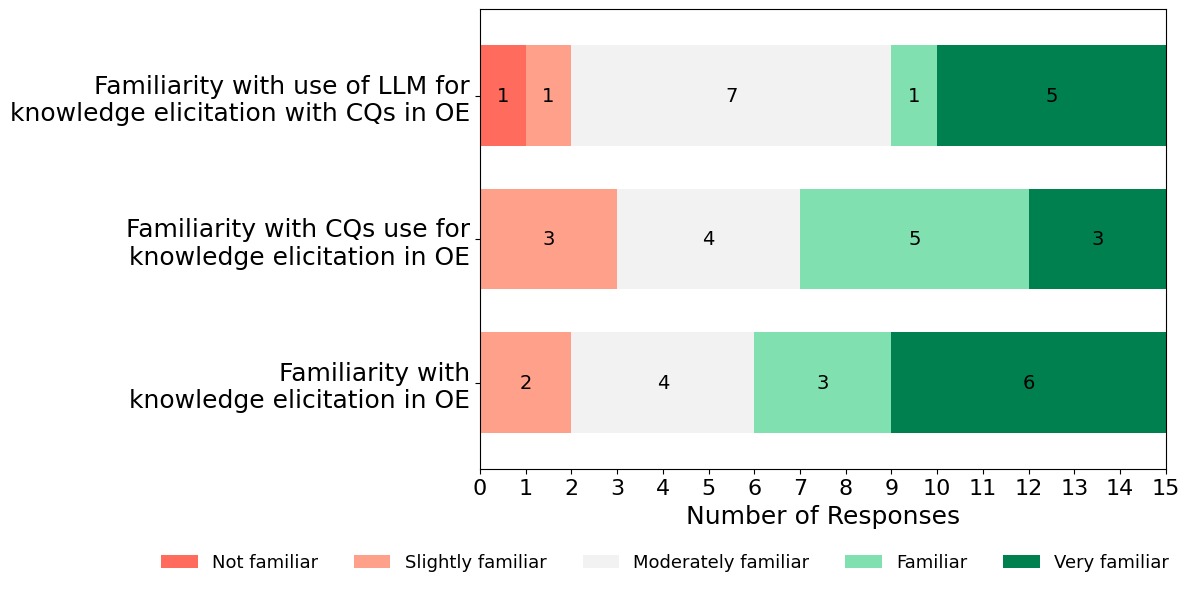

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

file_path = "demographic.xlsx"
data = pd.read_excel(file_path)

cols_interest = [
    "How familiar are you with knowledge elicitation for ontology engineering?",
    "How familiar are you with using Competency Questions for knowledge elicitation in ontology engineering?",
    "How familiar are you with using large language models with Competency Questions for knowledge elicitation in ontology engineering?"
]

short_names = [
    "Familiarity with\nknowledge elicitation in OE",
    "Familiarity with CQs use for\nknowledge elicitation in OE",
    "Familiarity with use of LLM for\nknowledge elicitation with CQs in OE"
]

counts = {col: data[col].value_counts().sort_index() for col in cols_interest}
df_counts = pd.DataFrame(counts).fillna(0).astype(int)
df_counts = df_counts.T
df_counts.index = short_names  

response_order = [
    "Not familiar",
    "Slightly familiar",
    "Moderately familiar",
    "Familiar",
    "Very familiar"
]
df_counts = df_counts[response_order].fillna(0)

colors = ["#ff6b5c", "#ffa08a", "#f2f2f2", "#80e0b0", "#007f4f"]

ax = df_counts.plot(
    kind="barh",
    stacked=True,
    figsize=(12, 6),
    color=colors,
    width=0.7,
    legend=False
)

for i, (idx, row) in enumerate(df_counts.iterrows()):
    cum_width = 0
    for j, val in enumerate(row):
        if val > 0:
            ax.text(
                cum_width + val/2, i, str(int(val)),
                va="center", ha="center", fontsize=14, color="black"
            )
        cum_width += val

plt.xlabel("Number of Responses", fontsize=18)
plt.ylabel("", fontsize=16)
plt.xticks(range(0, 16, 1), fontsize=16)
plt.yticks(fontsize=18)

custom_labels = [
    "Not familiar",
    "Slightly familiar",
    "Moderately familiar",
    "Familiar",
    "Very familiar"
]

legend_items = [Patch(facecolor=colors[i], label=custom_labels[i]) for i in range(len(colors))]

ax.legend(
    handles=legend_items,
    loc="upper center",
    bbox_to_anchor=(0.27, -0.15),
    ncol=5,
    frameon=False,
    fontsize=13
)

plt.xlim(0, 15)
plt.tight_layout()
plt.savefig("likert_scale_chart.png")

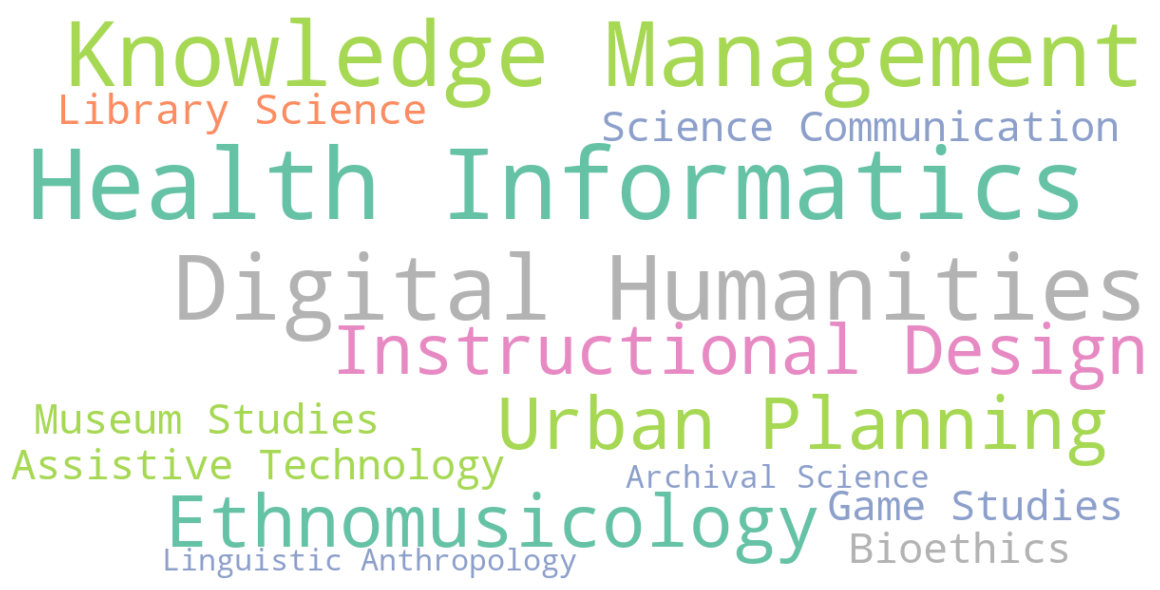

In [2]:
import pandas as pd
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from collections import Counter
import numpy as np

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 100

file_path = "demographic.xlsx"
df = pd.read_excel(file_path)

column_name = "Which knowledge domains are you experienced in?"

all_domains = []
for response in df[column_name].dropna():
    domains = [domain.strip() for domain in str(response).split(',')]
    all_domains.extend(domains)

freqs = Counter(all_domains)

wc = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    prefer_horizontal=0.9,
    collocations=False,
    colormap="Set2",
    min_font_size=12,
    max_words=200
).generate_from_frequencies(freqs)

plt.figure()
img_array = np.array(wc.to_image())
plt.imshow(img_array, interpolation="bilinear")
plt.axis("off")
plt.tight_layout()
plt.show()

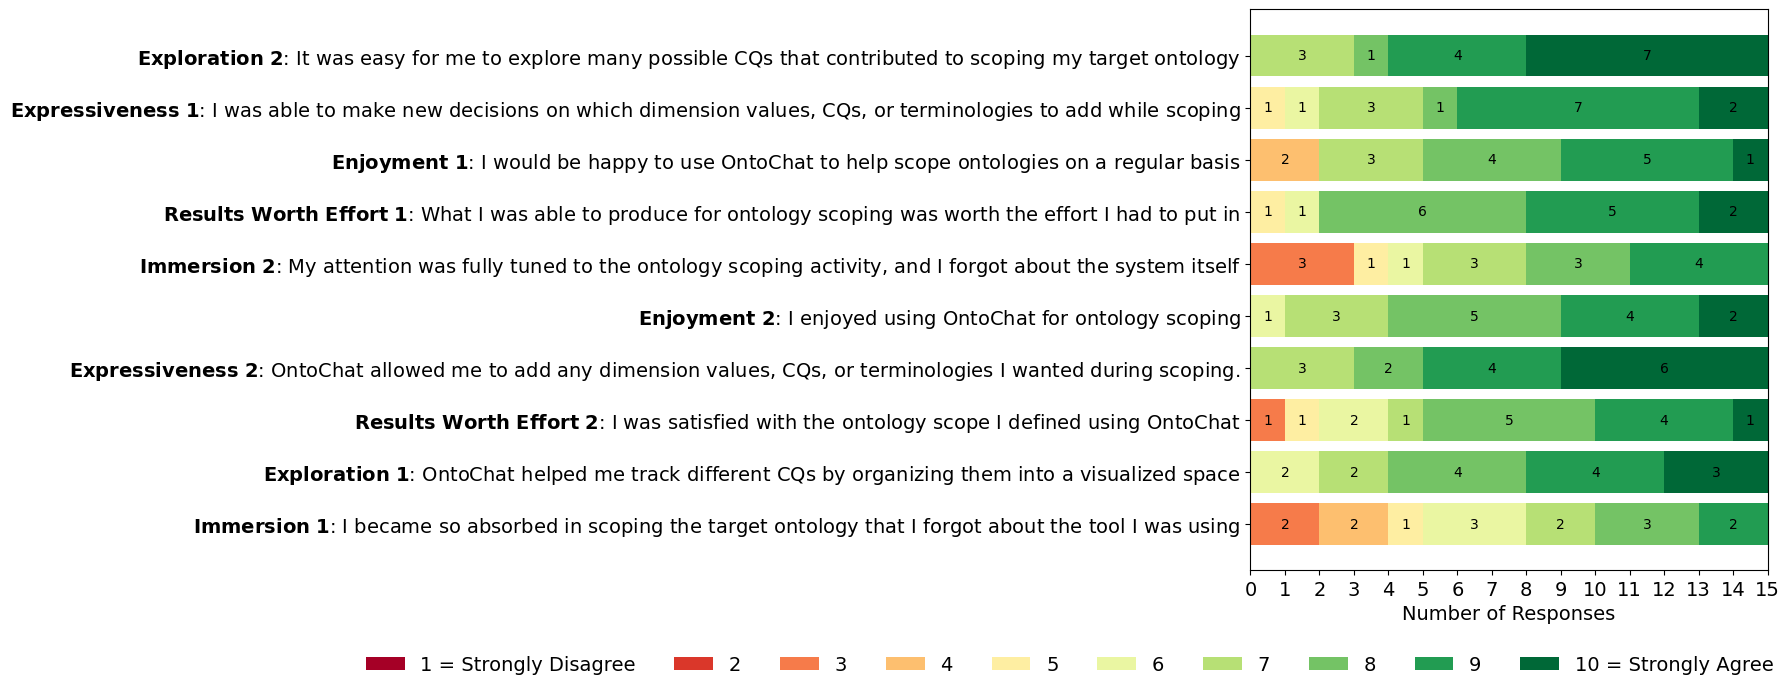

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

file_path = "csi_rating.xlsx"
df = pd.read_excel(file_path, sheet_name="Sheet1")

q_cols = list(df.columns[2:12])

question_titles = [
    "Immersion 1: I became so absorbed in scoping the target ontology that I forgot about the tool I was using",
    "Exploration 1: OntoChat helped me track different CQs by organizing them into a visualized space",
    "Results Worth Effort 2: I was satisfied with the ontology scope I defined using OntoChat",
    "Expressiveness 2: OntoChat allowed me to add any dimension values, CQs, or terminologies I wanted during scoping.",
    "Enjoyment 2: I enjoyed using OntoChat for ontology scoping",
    "Immersion 2: My attention was fully tuned to the ontology scoping activity, and I forgot about the system itself",
    "Results Worth Effort 1: What I was able to produce for ontology scoping was worth the effort I had to put in",
    "Enjoyment 1: I would be happy to use OntoChat to help scope ontologies on a regular basis",
    "Expressiveness 1: I was able to make new decisions on which dimension values, CQs, or terminologies to add while scoping",
    "Exploration 2: It was easy for me to explore many possible CQs that contributed to scoping my target ontology"
]

ratings = list(range(1, 11))

counts = []
for c in q_cols:
    s = pd.to_numeric(df[c], errors="coerce")
    counts.append([int((s == r).sum()) for r in ratings])
counts = np.array(counts)

fig, ax = plt.subplots(figsize=(18, 7))
left = np.zeros(len(q_cols))

cmap = plt.get_cmap("RdYlGn", len(ratings))
colors = [cmap(i) for i in range(len(ratings))]

for i, r in enumerate(ratings):
    bars = ax.barh(
        range(len(q_cols)),
        counts[:, i],
        left=left,
        label=str(r),
        color=colors[i]
    )

    for bar, val in zip(bars, counts[:, i]):
        if val > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_y() + bar.get_height() / 2,
                str(val),
                ha="center",
                va="center",
                fontsize=10,
                color="black"
            )

    left += counts[:, i]

ax.set_yticks(range(len(q_cols)))

def bold_prefix(label: str) -> str:
    if ":" in label:
        pref, rest = label.split(":", 1)
        pref = pref.strip().replace(" ", r"\ ")
        return rf"$\bf{{{pref}}}$:{rest}"
    return label

yticks_bold = [bold_prefix(t) for t in question_titles]

ax.set_yticks(range(len(q_cols)))
ax.set_yticklabels(yticks_bold, fontsize=14)

ax.set_xlabel("Number of Responses", fontsize=14)
ax.set_ylabel("")

legend_labels = [f"{r}" for r in ratings]
legend_labels[0] = "1 = Strongly Disagree"
legend_labels[-1] = "10 = Strongly Agree"

ax.legend(
    handles=ax.patches[::len(q_cols)],
    labels=legend_labels,
    bbox_to_anchor=(-0.35, -0.12),
    loc="upper center",
    ncol=len(ratings),
    frameon=False,
    fontsize=14
)

ax.set_xlim(0, 15)
plt.xticks(range(0, 16, 1), fontsize=14)

plt.tight_layout()
plt.show()

/var/folders/15/m1jrqzl52kbdjwj67cjmllvw0000gn/T/ipykernel_42902/455153497.py:94: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0,0,1,0.96])


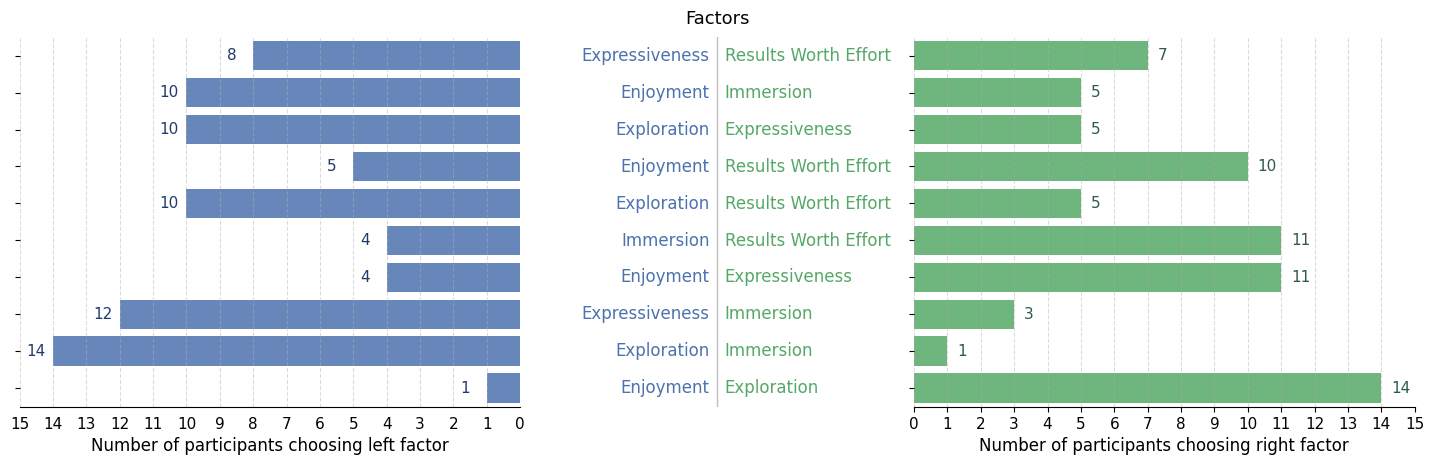

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from matplotlib.gridspec import GridSpec

file_path = "csi_rating.xlsx"
sheet_name = "Sheet1"
df = pd.read_excel(file_path, sheet_name=sheet_name)

pc_cols_named = [c for c in df.columns if isinstance(c, str) and re.search(r"\s+vs\.?\s+", c)]

triples = []
def split_pair(colname):
    a, b = re.split(r"\s+vs\.?\s+", colname.strip())
    return a.strip(), b.strip()

for col in pc_cols_named:
    L, R = split_pair(col)
    triples.append((col, L, R))

rows = []
for col, L, R in triples:
    s = df[col].astype(str).str.strip()
    lc = int((s == L).sum())
    rc = int((s == R).sum())
    rows.append({"left_label": L, "right_label": R, "left_count": lc, "right_count": rc,
                 "pair": f"{L} vs. {R}", "diff": abs(lc-rc)})

pc_df = pd.DataFrame(rows).sort_values("diff", ascending=False).reset_index(drop=True)

y = np.arange(len(pc_df))
left_vals  = pc_df["left_count"].to_numpy()
right_vals = pc_df["right_count"].to_numpy()

fig = plt.figure(figsize=(18, 4.8))
gs  = GridSpec(1, 3, width_ratios=[1.6, 1.2, 1.6], wspace=0.02)

axL = fig.add_subplot(gs[0,0])
axC = fig.add_subplot(gs[0,1])
axR = fig.add_subplot(gs[0,2])

axL.tick_params(axis='x', bottom=False, labelbottom=True)
axL.set_xticklabels([])

axL.barh(y, left_vals, color="#4C72B0", alpha=0.85)
axL.set_xlim(15, 0)
axL.set_xticks(range(0, 16, 1))
axL.set_xticklabels([str(t) for t in range(0,16)], fontsize=11)
axL.set_yticks(y); axL.set_yticklabels([])
axL.xaxis.grid(True, linestyle="--", alpha=0.45)
axL.yaxis.grid(False)
axL.set_xlabel("Number of participants choosing left factor", fontsize=12)

for yi, v in enumerate(left_vals):
    if v > 0:
        axL.text(v + 0.8, yi, f"{v}",
                 va="center", ha="left", fontsize=11,
                 color="#1f3b6d", clip_on=False, zorder=5)

axC.set_xlim(0, 1); axC.set_ylim(-0.5, len(pc_df)-0.5)
axC.axis("off")

for yi, (L, R) in enumerate(zip(pc_df["left_label"], pc_df["right_label"])):
    axC.text(0.48, yi, L, ha="right", va="center", fontsize=12, color="#4C72B0")
    axC.text(0.52, yi, R, ha="left",  va="center", fontsize=12, color="#55A868")

axC.text(
    0.5, len(pc_df) - 0.25, "Factors",
    ha="center", va="bottom",
    fontsize=13
)

axC.plot([0.50, 0.50], [-0.6, len(pc_df)-0.4], color="0.75", lw=1)

axR.barh(y, right_vals, color="#55A868", alpha=0.85)
axR.set_xlim(0, 15)
axR.set_xticks(range(0, 16, 1))
axR.set_xticklabels([str(t) for t in range(0,16)], fontsize=11)
axR.set_yticks(y); axR.set_yticklabels([])
axR.xaxis.grid(True, linestyle="--", alpha=0.45)
axR.yaxis.grid(False)
axR.set_xlabel("Number of participants choosing right factor", fontsize=12)

for yi, v in enumerate(right_vals):
    if v > 0:
        axR.text(v + 0.3, yi, f"{v}", va="center", ha="left", fontsize=11, color="#2d5a45")

for ax in (axL, axR):
    for spine in ["top", "right", "left"]:
        ax.spines[spine].set_visible(False)
    ax.set_ylim(-0.5, len(pc_df)-0.5)

plt.tight_layout(rect=[0,0,1,0.96])
plt.show()

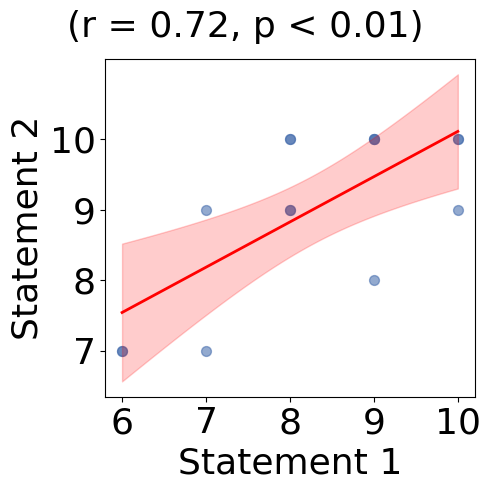

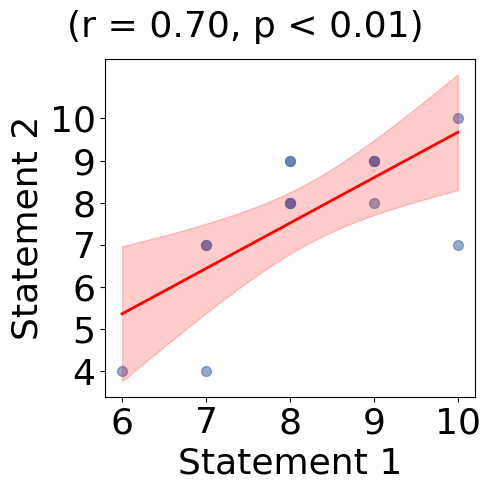

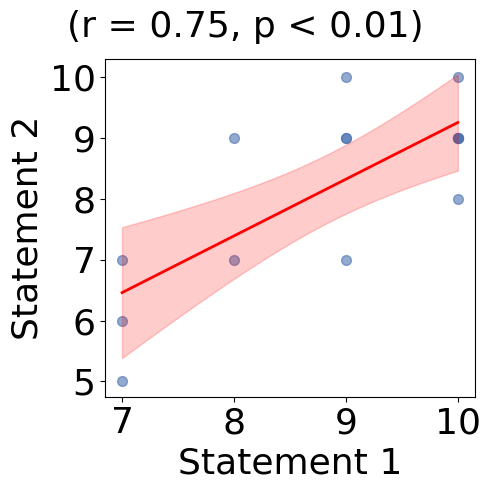

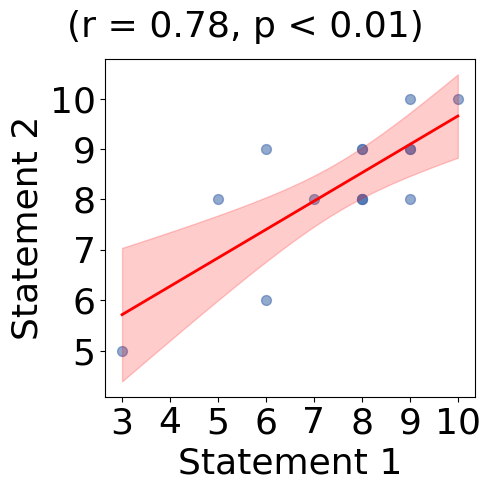

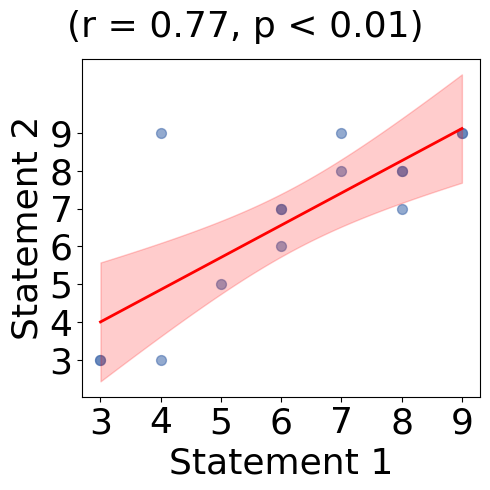

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, t
from sklearn.linear_model import LinearRegression
import matplotlib.lines as mlines
import matplotlib.patches as mpatches

file_path = "csi_rating.xlsx"
df = pd.read_excel(file_path, sheet_name="Sheet1")

factors = ["Exploration", "Enjoyment", "Expressiveness", "Results Worth Effort", "Immersion"]

item_cols = {f: [c for c in df.columns if f in str(c)] for f in factors}

scatter_color = "#4C72B0"

for f in factors:
    cols = item_cols[f]
    if len(cols) < 2:
        continue

    x = pd.to_numeric(df[cols[0]], errors="coerce")
    y = pd.to_numeric(df[cols[1]], errors="coerce")

    valid = ~(x.isna() | y.isna())
    x_valid, y_valid = x[valid].values, y[valid].values

    r, p = pearsonr(x_valid, y_valid)
    p_label = "< 0.01" if p < 0.01 else f"= {p:.3f}"

    plt.figure(figsize=(5, 5))
    
    plt.scatter(x_valid, y_valid, alpha=0.6, color=scatter_color, s=50)
    
    model = LinearRegression()
    X = x_valid.reshape(-1, 1)
    model.fit(X, y_valid)
    
    x_line = np.linspace(x_valid.min(), x_valid.max(), 100)
    y_pred = model.predict(x_line.reshape(-1, 1))
    
    plt.plot(x_line, y_pred, color="red", linewidth=2)
    
    y_fit = model.predict(X)
    residuals = y_valid - y_fit
    mse = np.sum(residuals**2) / (len(x_valid) - 2)
    
    x_mean = np.mean(x_valid)
    sxx = np.sum((x_valid - x_mean)**2)
    
    se = np.sqrt(mse * (1/len(x_valid) + (x_line - x_mean)**2 / sxx))
    
    t_val = t.ppf(0.975, len(x_valid) - 2)
    ci = t_val * se
    
    plt.fill_between(x_line, y_pred - ci, y_pred + ci, color="red", alpha=0.2)

    plt.xlabel("Statement 1", fontsize=26)
    plt.ylabel("Statement 2", fontsize=26)

    plt.xticks(np.arange(int(x_valid.min()), int(x_valid.max())+1, 1), fontsize=26)
    plt.yticks(np.arange(int(y_valid.min()), int(y_valid.max())+1, 1), fontsize=26)

    plt.suptitle(f"(r = {r:.2f}, p {p_label})", fontsize=26, y=0.97)

    dot = mlines.Line2D([], [], color=scatter_color, marker="o", linestyle="None",
                        markersize=8, alpha=0.6, label="Data points")
    line = mlines.Line2D([], [], color="red", linestyle="-", linewidth=2, label="Regression line")
    shade = mpatches.Patch(color="red", alpha=0.2, label="95% Confidence interval")

    plt.tight_layout()
    plt.show()

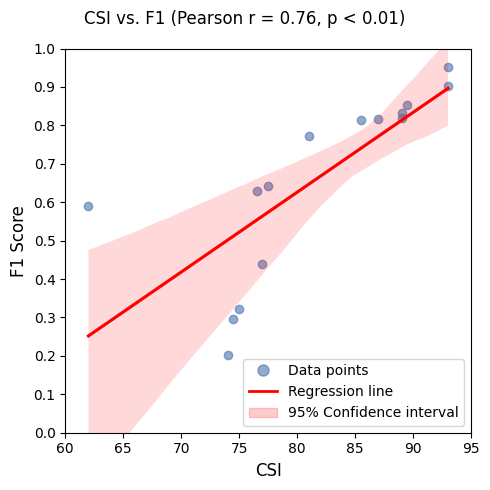

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

file_path = "csi_rating.xlsx"
df = pd.read_excel(file_path)

x = pd.to_numeric(df["CSI Score"], errors="coerce")
y = pd.to_numeric(df["F1"], errors="coerce")

mask = ~(x.isna() | y.isna())
r, p = pearsonr(x[mask], y[mask])
p_text = "p < 0.01" if p < 0.01 else f"p = {p:.3f}"

plt.figure(figsize=(5, 5))
scatter_color = "#4C72B0"

ax = sns.regplot(x=x, y=y, scatter_kws={"alpha":0.6, "color":scatter_color}, line_kws={"color":"red"})

plt.xlabel("CSI", fontsize=12)
plt.ylabel("F1 Score", fontsize=12)
plt.xlim(x.min(), x.max())
plt.ylim(0, 1)
plt.xticks(np.arange(int(x.min() // 10 * 10), int(x.max())+5, 5))
plt.yticks(np.arange(0, 1.1, 0.1))
plt.suptitle(f"CSI vs. F1 (Pearson r = {r:.2f}, {p_text})", y=0.97)

dot = mlines.Line2D([], [], color=scatter_color, marker="o", linestyle="None", markersize=8, alpha=0.6, label="Data points")
line = mlines.Line2D([], [], color="red", linestyle="-", linewidth=2, label="Regression line")
shade = mpatches.Patch(color="red", alpha=0.2, label="95% Confidence interval")
plt.legend(handles=[dot, line, shade], loc="lower right", frameon=True)

plt.tight_layout()
plt.show()

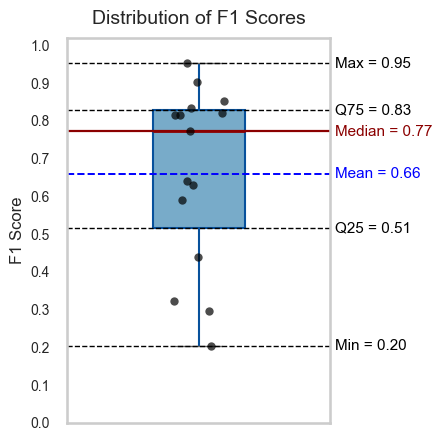

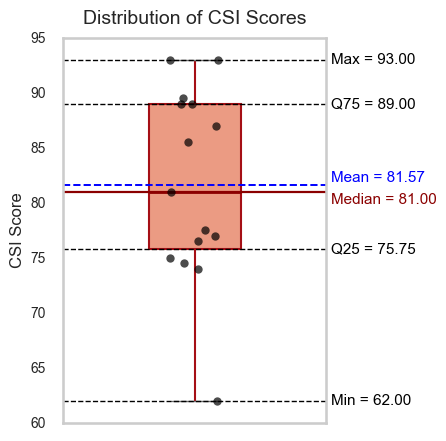

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.transforms import blended_transform_factory
import numpy as np

df = pd.read_excel("csi_rating.xlsx")
f1  = pd.to_numeric(df["F1"], errors="coerce").dropna()
csi = pd.to_numeric(df["CSI Score"], errors="coerce").dropna()

sns.set_theme(style="whitegrid")
sns.set_context("talk", font_scale=1.1)

def box_with_right_labels(data, title, ylabel, color, edge,
                          ylim=None, yticks=None):
    stats = {
        "Min":    float(data.min()),
        "Q25":    float(data.quantile(0.25)),
        "Median": float(data.median()),
        "Q75":    float(data.quantile(0.75)),
        "Max":    float(data.max()),
        "Mean":   float(data.mean()),
    }

    fig, ax = plt.subplots(figsize=(3.89, 5))
    plt.subplots_adjust(right=0.80)

    sns.boxplot(y=data, color=color, width=0.35,
                boxprops={"linewidth":1.5, "edgecolor":edge},
                whiskerprops={"linewidth":1.5, "color":edge},
                medianprops={"color":"darkred", "linewidth":2}, ax=ax)
    sns.stripplot(y=data, color="black", alpha=0.7, size=6, jitter=0.1, ax=ax)

    if ylim: ax.set_ylim(*ylim)
    if yticks is not None: ax.set_yticks(yticks)

    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(title, pad=10, fontsize=14)

    ax.tick_params(axis="both", which="major", labelsize=10)

    ax.yaxis.grid(False)
    ax.xaxis.grid(False)

    ax.axhline(stats["Mean"],   color="blue",    ls="--", lw=1.4)
    ax.axhline(stats["Median"], color="darkred", ls="-",  lw=1.6)
    for k in ["Min","Q25","Q75","Max"]:
        ax.axhline(stats[k], color="black", ls="--", lw=1)

    trans = blended_transform_factory(ax.transAxes, ax.transData)
    x_text = 1.02
    font_main = dict(va="center", ha="left", fontsize=11)

    mean_y, med_y = stats["Mean"], stats["Median"]
    if abs(mean_y - med_y) > 0.5:
        ax.text(x_text, mean_y+0.7, f"Mean = {mean_y:.2f}", color="blue", transform=trans, **font_main)
        ax.text(x_text, med_y-0.7, f"Median = {med_y:.2f}", color="darkred", transform=trans, **font_main)
    else:
        ax.text(x_text, mean_y, f"Mean = {mean_y:.2f}", color="blue", transform=trans, **font_main)
        ax.text(x_text, med_y, f"Median = {med_y:.2f}", color="darkred", transform=trans, **font_main)

    for k in ["Min","Q25","Q75","Max"]:
        ax.text(x_text, stats[k], f"{k} = {stats[k]:.2f}", color="black", transform=trans, **font_main)

    plt.show()

box_with_right_labels(
    f1, "Distribution of F1 Scores", "F1 Score",
    color="#6BAED6", edge="#08519C",
    ylim=(0, 1.02), yticks=[i/10 for i in range(0, 11)]
)

box_with_right_labels(
    csi, "Distribution of CSI Scores", "CSI Score",
    color="#FC9272", edge="#A50F15",
    yticks=np.arange(int(csi.min())//5*5, int(csi.max())+6, 5)
)

# Appendix: Manual Validation Guidelines for Term Matching

To ensure the reliability of the $F_1$ scores, all automated matches suggested by `gemini-embedding-001` were subjected to manual expert review. These guidelines define the formal criteria used to accept or reject a semantic match between participant-generated terms and the gold standard (the **WDV-CQ-HA dataset**).

---

### A. Acceptance Criteria (True Positives)
A match is marked as **Correct (1)** if it satisfies any of the following:

| Category | Description | Example |
| :--- | :--- | :--- |
| **Exact Match** | String-level identity. | *Author* $\leftrightarrow$ *Author* |
| **Morphological Variation** | Differences limited to pluralization, capitalization, or verb tense. | *Books* $\leftrightarrow$ *Book* |
| **Synonymy in Context** | Different words referring to the identical concept within the specific domain. | *Publication Date* $\leftrightarrow$ *Release Date* |
| **Lexical Overlap** | The core head noun is identical and represents the same scope. | *Scientific Researcher* $\leftrightarrow$ *Researcher* |

### B. Rejection Criteria (False Positives)
A match is marked as **Incorrect (0)** if it exhibits any of the following:

| Category | Description | Example |
| :--- | :--- | :--- |
| **Hierarchical Mismatch** | Relationship is Hypernymic (too broad) or Hyponymic (too specific). | *Musician* (Broad) $\leftrightarrow$ *Composer* (Specific) |
| **Semantic Proximity** | Terms are related in the same domain but represent distinct entities. | *Director* $\leftrightarrow$ *Actor* |
| **Category Mismatch** | One term is a property (attribute) while the other is a class (entity). | *Age* $\leftrightarrow$ *Person* |
| **Out of Domain** | The term is valid in general English but does not exist in the target domain. | *Price* $\leftrightarrow$ (Any non-commercial domain) |